# Generic THz spin-$1/2$ chain at finite temperature

This example describes a finite periodic XXZ spin chain in a longitudinal static field. It demonstrates:

- a magnetic Hamiltonian parametrized by $J_{xy}$, $J_z$, the Landé factor $g$, and the static field $B_0$;
- a canonical initial density matrix at $T=4$ K, distributed over several magnon-number sectors;
- magnetic-dipole excitation by a spatially uniform THz field, selecting total momentum $q\simeq0$;
- one-magnon absorption and interacting bimagnon excited-state absorption;
- a four-magnon truncation that closes the retained third-order pathways starting in the thermally relevant $N=0,1,2$ sectors; and
- a separate dense--sparse backend validation kept in the pure polarized ground state.

Natural units are used internally, with $\hbar=1$. Energies are expressed in meV, magnetic fields in tesla, $\mu_B=0.0578838$ meV/T, and $k_B=0.0861733$ meV/K. A physical delay in picoseconds is converted through $t_{\mathrm{internal}}=t_{\mathrm{ps}}/0.658212$, because $\hbar=0.658212$ meV ps.

In [23]:
from itertools import combinations
from pathlib import Path
from time import perf_counter
import sys

import matplotlib.pyplot as plt
import numpy as np

# Locate the project root when the notebook is launched from examples/
# or from another directory inside the repository.
current_directory = Path.cwd().resolve()
for candidate in (current_directory, *current_directory.parents):
    if (candidate / "projet_solver10.py").is_file():
        project_root = str(candidate)
        if project_root not in sys.path:
            sys.path.insert(0, project_root)
        break
else:
    raise RuntimeError("Could not locate the directory containing projet_solver10.py.")

from projet_solver10 import (
    ExcitationSectorModel,
    FrequencyPathway,
    PropagationInterval,
    SpectroscopyPlotter,
    SpectroscopyProtocol,
    SpectroscopySolver,
    ThermodynamicContext,
    standard_nq_protocol,
)

## 1. Generic magnetic Hamiltonian, thermal state, and excitation manifolds

We use the number-conserving XXZ Hamiltonian

$$
H=J_{xy}\sum_j\left(S_j^xS_{j+1}^x+S_j^yS_{j+1}^y\right)
+J_z\sum_jS_j^zS_{j+1}^z
-g\mu_BB_0\sum_jS_j^z,
$$

with periodic boundary conditions. The reference state $|G\rangle=|\uparrow\cdots\uparrow\rangle$ is fully polarized along the static field. A magnon is one downward spin deviation, so $n_j=1/2-S_j^z$ and its creation operator is $m_j^\dagger=S_j^-$. Relative to the polarized-state energy,

$$
H=(g\mu_BB_0-J_z)\sum_jn_j
+\frac{J_{xy}}{2}\sum_j\left(m_j^\dagger m_{j+1}+m_{j+1}^\dagger m_j\right)
+J_z\sum_jn_jn_{j+1}.
$$

At finite temperature the solver starts from the canonical density matrix

$$\rho_\beta=Z^{-1}e^{-H/(k_BT)},\qquad k_B=0.0861733\ {\rm meV/K},$$

not from a single wavefunction. At 4 K, the zero-, one-, and two-magnon sectors all have appreciable populations. A third-order ESA pathway that starts in $\mathcal H_N$ can reach $\mathcal H_{N+2}$, so keeping all pathways that start in $N=0,1,2$ requires

$$\mathcal H=\bigoplus_{N=0}^{4}\mathcal H_N,\qquad \dim\mathcal H_N=\binom{L}{N}.$$

The remaining pathways start in $N\geq3$ and carry only about $10^{-3}$ of the equilibrium population for the parameters below. The longitudinal exchange $J_z$ is also the nearest-neighbor magnon interaction: $J_z<0$ favors adjacent spin deviations and can produce a bimagnon bound state. The model is generic rather than fitted to one material; neglected terms include transverse static fields, Dzyaloshinskii--Moriya coupling, disorder, and interchain exchange.

In [24]:
MU_B_MEV_PER_T = 0.0578838
HBAR_MEV_PS = 0.658212
BOLTZMANN_MEV_PER_K = 0.08617333262


def excitation_basis(n_sites, n_magnons):
    return tuple(combinations(range(n_sites), n_magnons))


def build_xxz_sector_hamiltonian(
    n_sites, n_magnons, J_xy, J_z, g_factor, static_field
):
    basis = excitation_basis(n_sites, n_magnons)
    state_index = {state: index for index, state in enumerate(basis)}
    hamiltonian = np.zeros((len(basis), len(basis)), dtype=complex)

    # Relative to the fully up-polarized reference state:
    # H = (g mu_B B0 - J_z) sum n_j
    #   + (J_xy / 2) sum (m_j^dagger m_{j+1} + h.c.)
    #   + J_z sum n_j n_{j+1}.
    one_magnon_cost = g_factor * MU_B_MEV_PER_T * static_field - J_z
    hopping = 0.5 * J_xy

    for column, state in enumerate(basis):
        occupied = set(state)
        adjacent_pairs = sum(
            (site + 1) % n_sites in occupied for site in occupied
        )
        hamiltonian[column, column] = (
            n_magnons * one_magnon_cost + J_z * adjacent_pairs
        )

        for site in state:
            for neighbor in ((site - 1) % n_sites, (site + 1) % n_sites):
                if neighbor in occupied:
                    continue
                target = tuple(sorted((occupied - {site}) | {neighbor}))
                row = state_index[target]
                hamiltonian[row, column] += hopping

    assert np.allclose(hamiltonian, hamiltonian.conj().T)
    return basis, hamiltonian


def build_magnon_creation_block(source_basis, target_basis, probe_profile):
    target_index = {state: index for index, state in enumerate(target_basis)}
    block = np.zeros((len(target_basis), len(source_basis)), dtype=complex)
    for column, state in enumerate(source_basis):
        occupied = set(state)
        for site, amplitude in enumerate(probe_profile):
            if site in occupied or amplitude == 0:
                continue
            target = tuple(sorted((*state, site)))
            block[target_index[target], column] += amplitude
    return block


def uniform_thz_probe_profile(n_sites):
    # A far-field THz wavelength is much longer than the lattice spacing.
    # The normalized profile therefore selects total momentum q approximately 0.
    return np.ones(n_sites, dtype=complex) / np.sqrt(n_sites)


def make_spin_chain_model(
    n_sites, J_xy, J_z, g_factor, static_field, *, max_magnons=2
):
    if not 0 <= max_magnons <= n_sites:
        raise ValueError("max_magnons must lie between 0 and n_sites.")

    bases = {}
    hamiltonians = {}
    for n_magnons in range(max_magnons + 1):
        bases[n_magnons], hamiltonians[n_magnons] = (
            build_xxz_sector_hamiltonian(
                n_sites, n_magnons, J_xy, J_z, g_factor, static_field
            )
        )

    probe_profile = uniform_thz_probe_profile(n_sites)
    raising_blocks = {
        (n_magnons + 1, n_magnons): build_magnon_creation_block(
            bases[n_magnons], bases[n_magnons + 1], probe_profile
        )
        for n_magnons in range(max_magnons)
    }

    model = ExcitationSectorModel(
        hamiltonians,
        raising_blocks,
        initial_sector=0,
        boltzmann_constant=BOLTZMANN_MEV_PER_K,
    )
    return model, bases, hamiltonians, raising_blocks

## 2. One- and two-magnon spectra in the THz regime

In the one-magnon sector, the dispersion relative to the polarized ground state is

$$\omega(k)=g\mu_BB_0-J_z+J_{xy}\cos k.$$

The numerical values below describe a generic easy-axis ferromagnetic chain rather than a fit to one compound. The negative $J_{xy}$ places the bright $k=0$ magnon at the bottom of the band, while $J_z<0$ provides an attractive nearest-neighbor magnon interaction. The two-magnon transition energies enter the third-order signal through coherences between $\mathcal H_2$ and $\mathcal H_1$. The $N=3,4$ sectors are included as a finite-temperature convergence buffer; they are not interpreted as additional target resonances.

In [25]:
n_sites = 6
J_xy = -0.30          # meV, transverse exchange
J_z = -0.55           # meV, longitudinal exchange and magnon attraction
g_factor = 2.10
static_field = 7.1773 # tesla; keeps the bright one-magnon energy near 1.1224 meV
eta = 0.03            # meV, phenomenological linewidth
temperature = 4.0     # kelvin
max_magnons = 4       # closes third-order pathways starting in N = 0, 1, 2

thermal_context = ThermodynamicContext(temperature=temperature)
model, bases, hamiltonians, raising_blocks = make_spin_chain_model(
    n_sites,
    J_xy,
    J_z,
    g_factor,
    static_field,
    max_magnons=max_magnons,
)


def populations_by_sector(density_state):
    return {
        int(sector): float(
            np.trace(block.as_matrix()).real
        )
        for (sector, bra_sector), block in sorted(density_state.blocks.items())
        if sector == bra_sector
    }


thermal_state = model.equilibrium_state(thermal_context)
thermal_sector_populations = populations_by_sector(thermal_state)

# The full six-site Hilbert space is only used to quantify the truncation.
full_model, _, _, _ = make_spin_chain_model(
    n_sites,
    J_xy,
    J_z,
    g_factor,
    static_field,
    max_magnons=n_sites,
)
full_thermal_state = full_model.equilibrium_state(thermal_context)
full_sector_populations = populations_by_sector(full_thermal_state)
state_truncation_weight = sum(
    population
    for sector, population in full_sector_populations.items()
    if sector > max_magnons
)
pathway_truncation_weight = sum(
    population
    for sector, population in full_sector_populations.items()
    if sector + 2 > max_magnons
)

one_magnon_cost = g_factor * MU_B_MEV_PER_T * static_field - J_z
one_magnon_energies = np.linalg.eigvalsh(hamiltonians[1])
two_magnon_energies = np.linalg.eigvalsh(hamiltonians[2])
k_points = 2.0 * np.pi * np.arange(n_sites) / n_sites
expected_one_magnon = one_magnon_cost + J_xy * np.cos(k_points)
bright_k0_energy = one_magnon_cost + J_xy

assert np.allclose(
    np.sort(one_magnon_energies), np.sort(expected_one_magnon), atol=1e-12
)
assert [model.dimension(sector) for sector in model.sectors()] == [1, 6, 15, 20, 15]
assert model.initial_condition().sector == 0
assert np.isclose(sum(thermal_sector_populations.values()), 1.0)
assert pathway_truncation_weight < 2e-3
assert state_truncation_weight < 1e-3
assert np.allclose(
    np.abs(raising_blocks[(1, 0)][:, 0]),
    np.ones(n_sites) / np.sqrt(n_sites),
)

print("Generic XXZ parameters")
print(f"  J_xy = {J_xy:.3f} meV")
print(f"  J_z  = {J_z:.3f} meV")
print(f"  g     = {g_factor:.3f}")
print(f"  B_0   = {static_field:.4f} T")
print(f"  T     = {temperature:.1f} K")
print(f"  eta   = {eta:.3f} meV, corresponding to T2 ~ {HBAR_MEV_PS / eta:.2f} ps")
print("Sector dimensions:", {sector: model.dimension(sector) for sector in model.sectors()})
print(f"Total Hilbert dimension: {sum(model.dimension(s) for s in model.sectors())}")
print("Full-space thermal populations:")
for sector, population in full_sector_populations.items():
    print(f"  P(N={sector}) = {population:.6e}")
print(f"State weight omitted above N={max_magnons}: {state_truncation_weight:.3e}")
print(
    "Weight of initial sectors whose third-order paths can leave "
    f"N <= {max_magnons}: {pathway_truncation_weight:.3e}"
)
print(
    f"One-magnon band: {one_magnon_energies.min():.4f} to "
    f"{one_magnon_energies.max():.4f} meV"
)
print(f"Uniform-THz bright k=0 energy: {bright_k0_energy:.4f} meV")
print(
    f"Two-magnon energies: {two_magnon_energies.min():.4f} to "
    f"{two_magnon_energies.max():.4f} meV"
)

Generic XXZ parameters
  J_xy = -0.300 meV
  J_z  = -0.550 meV
  g     = 2.100
  B_0   = 7.1773 T
  T     = 4.0 K
  eta   = 0.030 meV, corresponding to T2 ~ 21.94 ps
Sector dimensions: {0: 1, 1: 6, 2: 15, 3: 20, 4: 15}
Total Hilbert dimension: 57
Full-space thermal populations:
  P(N=0) = 8.853308e-01
  P(N=1) = 1.027335e-01
  P(N=2) = 1.090758e-02
  P(N=3) = 9.547005e-04
  P(N=4) = 6.906641e-05
  P(N=5) = 4.118975e-06
  P(N=6) = 2.247611e-07
State weight omitted above N=4: 4.344e-06
Weight of initial sectors whose third-order paths can leave N <= 4: 1.028e-03
One-magnon band: 1.1224 to 1.7224 meV
Uniform-THz bright k=0 energy: 1.1224 meV
Two-magnon energies: 2.1108 to 3.3155 meV


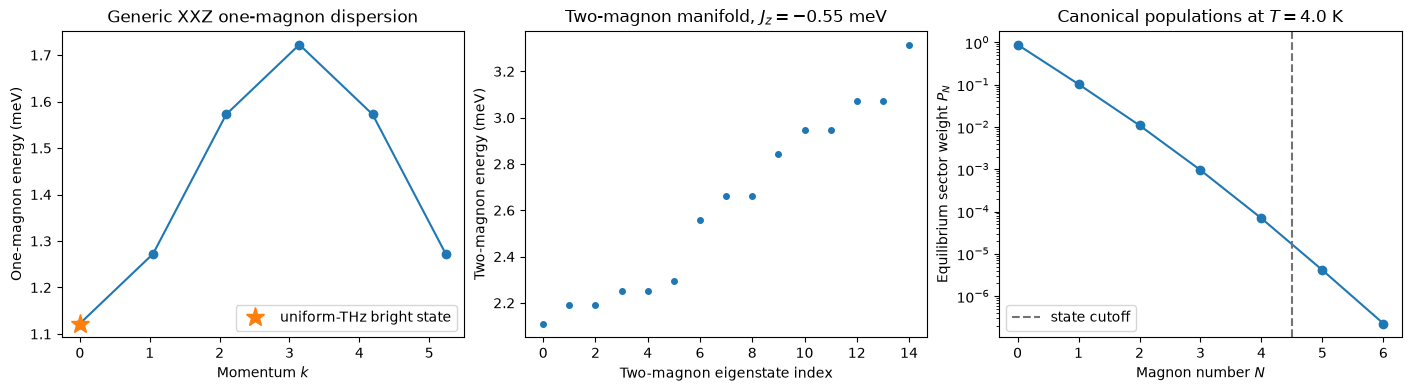

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 3.8), constrained_layout=True)
axes[0].plot(k_points, expected_one_magnon, "o-")
axes[0].plot(0.0, bright_k0_energy, "*", markersize=14, label="uniform-THz bright state")
axes[0].set_xlabel(r"Momentum $k$")
axes[0].set_ylabel("One-magnon energy (meV)")
axes[0].set_title("Generic XXZ one-magnon dispersion")
axes[0].legend()

axes[1].plot(
    np.arange(two_magnon_energies.size),
    np.sort(two_magnon_energies),
    "o",
    markersize=4,
)
axes[1].set_xlabel("Two-magnon eigenstate index")
axes[1].set_ylabel("Two-magnon energy (meV)")
axes[1].set_title(rf"Two-magnon manifold, $J_z={J_z:.2f}$ meV")

thermal_sectors = np.asarray(sorted(full_sector_populations))
thermal_populations = np.asarray(
    [full_sector_populations[sector] for sector in thermal_sectors]
)
axes[2].semilogy(thermal_sectors, thermal_populations, "o-")
axes[2].axvline(max_magnons + 0.5, color="0.45", linestyle="--", label="state cutoff")
axes[2].set_xticks(thermal_sectors)
axes[2].set_xlabel("Magnon number $N$")
axes[2].set_ylabel(r"Equilibrium sector weight $P_N$")
axes[2].set_title(rf"Canonical populations at $T={temperature:.1f}$ K")
axes[2].legend()

## 3. Thermal model and pure-state backend agreement

`ExcitationSectorModel` diagonalizes each excitation manifold separately and transforms every rectangular transition block as

$$\widetilde M_{ts}=U_t^\dagger M_{ts}U_s.$$

The transverse magnetic field of the THz pulse couples through $M^x\propto\sum_j(S_j^++S_j^-)$. Its excitation-raising part $\sum_jS_j^-$ increases the magnon number even though it lowers the microscopic spin projection. The finite-temperature calculation passes `ThermodynamicContext(temperature=4.0)` to the sparse solver, which asks the model for $\rho_\beta$ instead of using its default pure state.

Backend agreement is tested separately, as a numerical control, with the original $N_{\max}=2$ model and its pure polarized ground state. This keeps the dense calculation small and prevents the physical truncation study from being confused with a backend comparison.

In [27]:
sparse_solver = SpectroscopySolver(
    backend="sparse_sector", eta=eta, krylov_tolerance=1e-11
)
sparse_solver.feed_model(model, context=thermal_context)

zero_temperature_solver = SpectroscopySolver(
    backend="sparse_sector", eta=eta, krylov_tolerance=1e-11
)
zero_temperature_solver.feed_model(model)

reference_model, _, _, _ = make_spin_chain_model(
    n_sites,
    J_xy,
    J_z,
    g_factor,
    static_field,
    max_magnons=2,
)
reference_sparse_solver = SpectroscopySolver(
    backend="sparse_sector", eta=eta, krylov_tolerance=1e-11
)
reference_sparse_solver.feed_model(reference_model)
reference_dense_solver = SpectroscopySolver(
    backend="dense_liouville", eta=eta, cache_resolvents=False
)
reference_dense_solver.feed_model(reference_model)

assert (
    reference_sparse_solver.summary()["total_dimension"]
    == reference_dense_solver.summary()["total_dimension"]
)
assert model.transition_decomposition() == "explicit_sector"

print("Thermal calculation backend:", sparse_solver.summary()["backend"])
print("Thermal sectors:", sparse_solver.summary()["sector_dimensions"])
print("Pure-state validation sectors:", reference_sparse_solver.summary()["sector_dimensions"])
print("Dense validation backend:", reference_dense_solver.summary()["backend"])
print("Transition decomposition:", model.transition_decomposition())

Thermal calculation backend: sparse_sector
Thermal sectors: {0: 1, 1: 6, 2: 15, 3: 20, 4: 15}
Pure-state validation sectors: {0: 1, 1: 6, 2: 15}
Dense validation backend: dense_liouville
Transition decomposition: explicit_sector


## 4. Linear THz response at 4 K and the $q\simeq0$ selection rule

At zero temperature, a single ket-side excitation creates the coherence $|1\mathrm{mag}\rangle\langle G|$. A spatially uniform far-field THz pulse conserves crystal momentum and selects the $k=0$ one-magnon eigenstate. At 4 K, the initial density matrix also contains one- and two-magnon populations. The same interaction therefore adds thermally activated $N\rightarrow N+1$ hot-band coherences while preserving total momentum.

The main curves compare the sparse response at 4 K with the same four-sector-truncated model in its pure ground state. Dense--sparse agreement is checked independently with the original pure-state $N_{\max}=2$ reference model.

In [28]:
linear_pathway = FrequencyPathway(
    name="linear",
    interactions=("Ku",),
    component="linear",
)
linear_protocol = SpectroscopyProtocol(
    intervals=(PropagationInterval("omega", "frequency", coherence_order=1),),
    name="linear_frequency",
)

omega = np.linspace(0.55, 1.90, 101)  # meV


def calculate_linear_response(solver):
    return np.asarray(
        [
            solver.calc_pathway(
                linear_pathway, linear_protocol, {"omega": frequency}
            ).value
            for frequency in omega
        ]
    )


linear_thermal = calculate_linear_response(sparse_solver)
linear_zero_temperature = calculate_linear_response(zero_temperature_solver)
linear_reference_sparse = calculate_linear_response(reference_sparse_solver)
linear_reference_dense = calculate_linear_response(reference_dense_solver)

linear_backend_residual = np.max(
    np.abs(linear_reference_sparse - linear_reference_dense)
)
linear_peak_energy = omega[np.argmax(np.abs(linear_zero_temperature))]
thermal_change = np.max(
    np.abs(linear_thermal - linear_zero_temperature)
) / np.max(np.abs(linear_zero_temperature))

assert np.all(np.isfinite(linear_thermal))
assert np.allclose(
    linear_reference_sparse, linear_reference_dense, rtol=1e-8, atol=1e-9
)
assert abs(linear_peak_energy - bright_k0_energy) < 2.0 * (omega[1] - omega[0])
print(f"Pure-ground-state peak: {linear_peak_energy:.4f} meV")
print(f"Expected k=0 energy: {bright_k0_energy:.4f} meV")
print(f"Maximum relative thermal change: {thermal_change:.3e}")
print(f"Pure-state dense--sparse residual: {linear_backend_residual:.3e}")

Pure-ground-state peak: 1.1170 meV
Expected k=0 energy: 1.1224 meV
Maximum relative thermal change: 1.075e-01
Pure-state dense--sparse residual: 3.972e-15


Text(0.5, 1.0, 'Pure-ground-state $N_{\\max}=2$ validation')

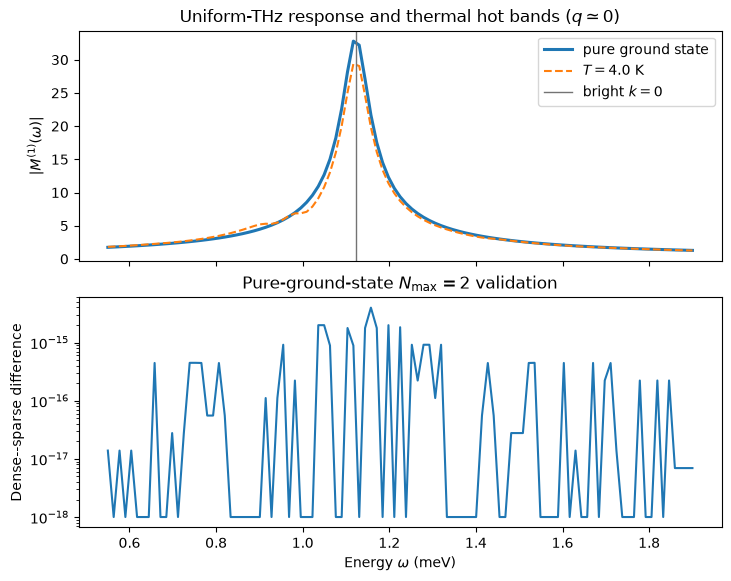

In [29]:
fig, axes = plt.subplots(
    2, 1, figsize=(7.2, 5.7), sharex=True, constrained_layout=True
)
axes[0].plot(omega, np.abs(linear_zero_temperature), label="pure ground state", linewidth=2.2)
axes[0].plot(omega, np.abs(linear_thermal), "--", label=rf"$T={temperature:.1f}$ K")
axes[0].axvline(bright_k0_energy, color="0.45", linewidth=1.0, label=r"bright $k=0$")
axes[0].set_ylabel(r"$|M^{(1)}(\omega)|$")
axes[0].set_title(r"Uniform-THz response and thermal hot bands ($q\simeq0$)")
axes[0].legend()
axes[1].semilogy(
    omega,
    np.maximum(np.abs(linear_reference_sparse - linear_reference_dense), 1e-18),
)
axes[1].set_xlabel(r"Energy $\omega$ (meV)")
axes[1].set_ylabel("Dense--sparse difference")
axes[1].set_title(r"Pure-ground-state $N_{\max}=2$ validation")

## 5. Third-order rephasing response and bimagnon ESA at 4 K

We retain the conventional pathway labels

$$R_{\mathrm{GSB}}=(B_u,B_d,K_u),\qquad R_{\mathrm{SE}}=(B_u,K_u,B_d),$$

and

$$R_{\mathrm{ESA}}=(B_u,K_u,K_u).$$

All three pathways have coherence history $q=(-1,0,+1)$. For a pure ground state, ESA maps $\mathcal H_0\rightarrow\mathcal H_1\rightarrow\mathcal H_2$ and leaves a $|2\mathrm{mag}\rangle\langle1\mathrm{mag}|$ emission coherence. At 4 K, the same algebra acts on every populated diagonal block of $\rho_\beta$: an ESA branch starting in $\mathcal H_N$ can end between $\mathcal H_{N+2}$ and $\mathcal H_{N+1}$. The labels GSB, SE, and ESA therefore identify pathway topologies, not exclusively processes that start from the ground state.

The $N_{\max}=4$ model contains complete third-order branches for initial $N=0,1,2$, including the target bimagnon branch. Paths starting from $N\geq3$ can hit the cutoff; their combined equilibrium weight is $1.03\times10^{-3}$. The plotted window remains centered on the principal one-magnon and bimagnon resonances.

Because a mixed initial state launches each pathway from several diagonal density blocks, the 2D scan is substantially more expensive than the pure-state calculation. The code defaults to a small executable grid; set `production_grid=True` to recover the finer $21\times25$ grid used for a publication-quality map.

In [30]:
pathway_se = FrequencyPathway(
    name="SE",
    interactions=("Bu", "Ku", "Bd"),
    component="rephasing",
)
pathway_gsb = FrequencyPathway(
    name="GSB",
    interactions=("Bu", "Bd", "Ku"),
    component="rephasing",
)
pathway_esa = FrequencyPathway(
    name="ESA",
    interactions=("Bu", "Ku", "Ku"),
    component="rephasing",
)

protocol_1q = standard_nq_protocol(
    order=1,
    nq_interval=1,
    detection_interval=3,
    n_interactions=3,
    nq_axis="omega_1q",
    detection_axis="omega_emit",
)

production_grid = True
if production_grid:
    omega_1q = np.linspace(-1.55, -0.55, 60)  # meV
    omega_emit = np.linspace(0.55, 1.55, 60)  # meV
else:
    # Executable tutorial grid; use production_grid=True for final figures.
    omega_1q = np.linspace(-1.45, -0.85, 5)
    omega_emit = np.linspace(0.55, 1.55, 6)
result_rephasing = sparse_solver.generate_spectrum(
    protocol_1q,
    axes={"omega_1q": omega_1q, "omega_emit": omega_emit},
    fixed_coordinates={"t2": 0.0},
    pathways=(pathway_gsb, pathway_se, pathway_esa),
)

gsb = result_rephasing.pathways["GSB"]
se = result_rephasing.pathways["SE"]
esa = result_rephasing.pathways["ESA"]
rephasing = result_rephasing.components["rephasing"]
reconstruction_residual = np.max(np.abs(rephasing - (gsb + se + esa)))
reference_amplitude = max(np.max(np.abs(gsb)), np.max(np.abs(se)))

assert np.all(np.isfinite(rephasing))
assert np.max(np.abs(esa)) > 1e-6 * reference_amplitude
assert reconstruction_residual < 1e-10

peak_index = np.unravel_index(np.argmax(np.abs(rephasing)), rephasing.shape)
print(f"Pathway reconstruction residual: {reconstruction_residual:.3e}")
print(f"Temperature: {temperature:.1f} K")
print(f"Maximum ESA amplitude: {np.max(np.abs(esa)):.6g}")
print("Strongest total rephasing coordinate:")
print(f"  omega_1q   = {omega_1q[peak_index[0]]:.4f} meV")
print(f"  omega_emit = {omega_emit[peak_index[1]]:.4f} meV")

Pathway reconstruction residual: 0.000e+00
Temperature: 4.0 K
Maximum ESA amplitude: 1513.47
Strongest total rephasing coordinate:
  omega_1q   = -1.1263 meV
  omega_emit = 1.1093 meV


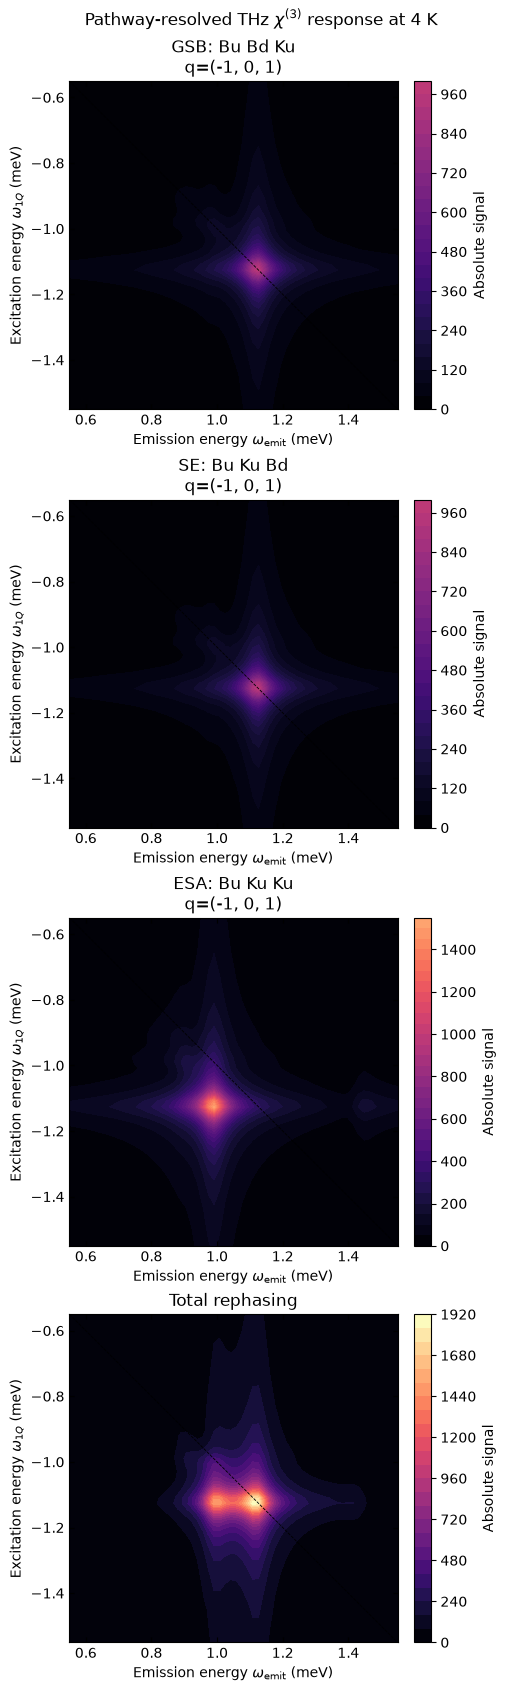

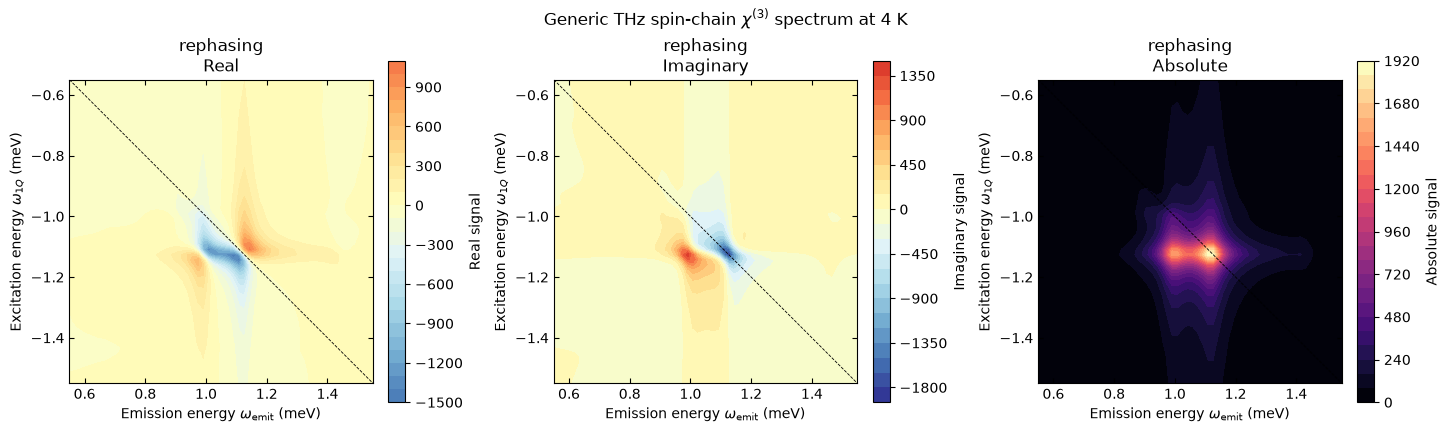

In [31]:
plotter = SpectroscopyPlotter(detection_phase=0.0)

pathway_plot = plotter.plot_spectrum_result(
    result_rephasing,
    params={
        "source": "pathways",
        "names": ["GSB", "SE", "ESA"],
        "view": "abs",
        "normalization": "global",
        "labels": (
            r"Emission energy $\omega_{\mathrm{emit}}$ (meV)",
            r"Excitation energy $\omega_{1Q}$ (meV)",
        ),
        "title": r"Pathway-resolved THz $\chi^{(3)}$ response at 4 K",
        "diagonals": "auto",
        "style": {"abs_cmap": "magma", "levels": 30, "contour_lines": False},
    },
)

total_plot = plotter.plot_spectrum_result(
    result_rephasing,
    params={
        "source": "components",
        "names": ["rephasing"],
        "view": "all",
        "normalization": "row",
        "labels": (
            r"Emission energy $\omega_{\mathrm{emit}}$ (meV)",
            r"Excitation energy $\omega_{1Q}$ (meV)",
        ),
        "title": r"Generic THz spin-chain $\chi^{(3)}$ spectrum at 4 K",
        "diagonals": "auto",
        "style": {"cmap": "RdYlBu_r", "abs_cmap": "magma", "levels": 30, "contour_lines": False},
    },
)

## 6. Pure-ground-state dense--sparse scaling

For the backend benchmark we deliberately return to the original pure ground state and truncate at two excitations,

$$D(L)=1+L+\binom{L}{2}.$$

This isolates numerical scaling from the separate finite-temperature convergence question. The dense backend stores Liouville matrices with $D^4$ complex entries. The sparse backend does not materialize these matrices, although a frequency-domain calculation still carries density vectors with up to $D^2$ entries. We time backend construction and one linear-response point for $L=4,\ldots,8$. Memory curves are structural estimates for one dense Liouville matrix and one sparse density vector; caches and temporary solver workspaces require additional memory.

In [32]:
def benchmark_backend(benchmark_model, backend_name):
    options = (
        {"cache_resolvents": False}
        if backend_name == "dense_liouville"
        else {"krylov_tolerance": 1e-11}
    )
    solver = SpectroscopySolver(backend=backend_name, eta=eta, **options)
    start = perf_counter()
    solver.feed_model(benchmark_model)
    build_time = perf_counter() - start

    start = perf_counter()
    value = solver.calc_pathway(
        linear_pathway, linear_protocol, {"omega": bright_k0_energy}
    ).value
    solve_time = perf_counter() - start
    return build_time, solve_time, value


benchmark_rows = []
for length in range(4, 9):
    benchmark_model, _, _, _ = make_spin_chain_model(
        length,
        J_xy,
        J_z,
        g_factor,
        static_field,
        max_magnons=2,
    )
    dimension = sum(benchmark_model.dimension(s) for s in benchmark_model.sectors())
    dense_build, dense_solve, dense_value = benchmark_backend(
        benchmark_model, "dense_liouville"
    )
    sparse_build, sparse_solve, sparse_value = benchmark_backend(
        benchmark_model, "sparse_sector"
    )
    assert np.allclose(sparse_value, dense_value, rtol=1e-8, atol=1e-9)
    benchmark_rows.append(
        {
            "L": length,
            "D": dimension,
            "dense_build": dense_build,
            "dense_solve": dense_solve,
            "sparse_build": sparse_build,
            "sparse_solve": sparse_solve,
            "residual": abs(sparse_value - dense_value),
        }
    )

print(" L    D   dense build  sparse build  dense solve  sparse solve  residual")
for row in benchmark_rows:
    print(
        f"{row['L']:2d}  {row['D']:3d}   {row['dense_build']:10.4f}  "
        f"{row['sparse_build']:11.4f}  {row['dense_solve']:10.4f}  "
        f"{row['sparse_solve']:11.4f}  {row['residual']:.2e}"
    )

 L    D   dense build  sparse build  dense solve  sparse solve  residual
 4   11       0.0368       0.0003      0.0581       0.0022  8.08e-28
 5   16       0.1064       0.0002      0.1348       0.0018  1.01e-27
 6   22       0.2732       0.0002      0.2160       0.0024  1.72e-27
 7   29       0.6315       0.0003      0.2887       0.0027  6.06e-28
 8   37       1.3312       0.0002      0.4278       0.0040  1.21e-27


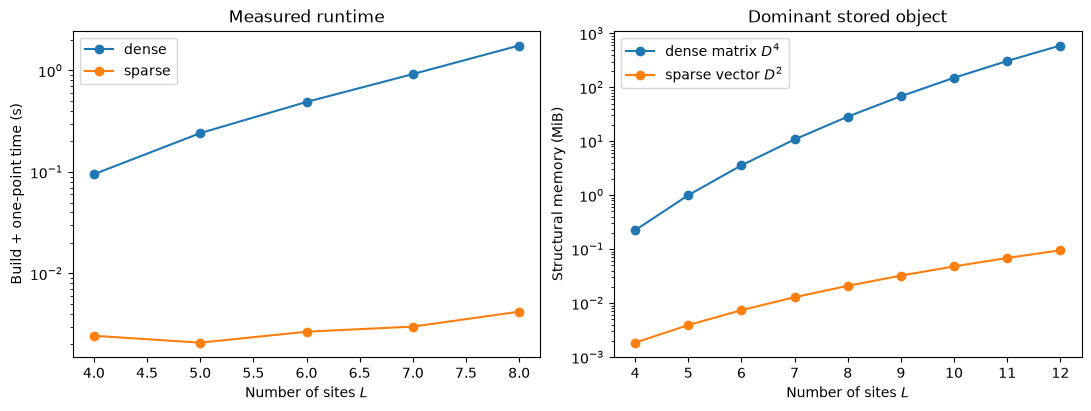

In [33]:
timed_lengths = np.asarray([row["L"] for row in benchmark_rows])
dense_total_times = np.asarray(
    [row["dense_build"] + row["dense_solve"] for row in benchmark_rows]
)
sparse_total_times = np.asarray(
    [row["sparse_build"] + row["sparse_solve"] for row in benchmark_rows]
)

memory_lengths = np.arange(4, 13)
memory_dimensions = 1 + memory_lengths + memory_lengths * (memory_lengths - 1) // 2
complex_bytes = np.dtype(np.complex128).itemsize
dense_matrix_mib = complex_bytes * memory_dimensions**4 / 2**20
sparse_vector_mib = complex_bytes * memory_dimensions**2 / 2**20

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0), constrained_layout=True)
axes[0].semilogy(timed_lengths, dense_total_times, "o-", label="dense")
axes[0].semilogy(timed_lengths, sparse_total_times, "o-", label="sparse")
axes[0].set_xlabel("Number of sites $L$")
axes[0].set_ylabel("Build + one-point time (s)")
axes[0].set_title("Measured runtime")
axes[0].legend()

axes[1].semilogy(memory_lengths, dense_matrix_mib, "o-", label=r"dense matrix $D^4$")
axes[1].semilogy(memory_lengths, sparse_vector_mib, "o-", label=r"sparse vector $D^2$")
axes[1].set_xlabel("Number of sites $L$")
axes[1].set_ylabel("Structural memory (MiB)")
axes[1].set_title("Dominant stored object")
axes[1].legend()

## 7. What this example establishes

1. The model is a generic XXZ spin-$1/2$ chain in a longitudinal field, with magnetic parameters in meV and tesla.
2. `ExcitationSectorModel` constructs the canonical density matrix requested by `ThermodynamicContext`; the model-specific Boltzmann constant is supplied in meV/K.
3. At 4 K, the full six-site model has sector weights $P_0=0.8853$, $P_1=0.1027$, and $P_2=0.0109$, so a pure-ground-state approximation misses visible thermal corrections.
4. Extending the sparse calculation to $N_{\max}=4$ makes all third-order pathways starting in $N=0,1,2$ available. Only $4.34\times10^{-6}$ of the equilibrium state lies above the retained Hilbert space, while pathways starting in sectors that can hit the boundary carry $1.03\times10^{-3}$.
5. A spatially uniform far-field THz probe conserves momentum: the zero-temperature response selects the bright $k=0$ magnon, while finite temperature adds momentum-compatible hot bands.
6. The same magnetic operator connects successive manifolds and produces a finite interacting-bimagnon ESA contribution.
7. Dense--sparse agreement and scaling remain a separate pure-ground-state, $N_{\max}=2$ numerical validation.

The parameters remain illustrative rather than fitted to a specific compound. The calculation assumes exact magnon-number conservation and a phenomenological linewidth. It does not include thermal relaxation or detailed balance in dissipative channels, transverse static fields, Dzyaloshinskii--Moriya coupling, interchain exchange, disorder, or the thermodynamic limit. The quoted $10^{-3}$ pathway-boundary weight is a population diagnostic, not a rigorous error bound on every spectral pixel.